# EDA & Pre-Processing: Real data (Closed Eyes in the Wild)

### Import Libraries

In [92]:
import os
from PIL import Image, ImageDraw, UnidentifiedImageError
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

import hashlib
from sklearn.model_selection import train_test_split

### Load images into Data Frame

In [70]:
# Define the base directory
base_path = '/Users/peterthyssen/Downloads/dataset_B_FacialImages 2'

# Define the subdirectories and file paths
closed_face_dir = os.path.join(base_path, 'ClosedFace')
open_face_dir = os.path.join(base_path, 'OpenFace')
closed_face_info = os.path.join(base_path, 'EyeCoordinatesInfo_ClosedFace.txt')
open_face_info = os.path.join(base_path, 'EyeCoordinatesInfo_OpenFace.txt')

In [71]:
def load_images_and_metadata(base_folder):
    # Initialize an empty list to store data
    data = []

    # Iterate through the categories in the images folder (ClosedFace, OpenFace)
    for category in ['ClosedFace', 'OpenFace']:
        category_path = os.path.join(base_folder, category)
        
        # Check if the path is a directory
        if os.path.isdir(category_path):
            
            # Iterate through the image files in the category directory
            for img_file in os.listdir(category_path):
                
                # Process only .jpg files
                if img_file.endswith('.jpg'):
                    img_path = os.path.join(category_path, img_file)
                    
                    # Open the image using PIL
                    img = Image.open(img_path)
                    
                    # Append the collected data to the list
                    data.append({
                        'category': category,          # ClosedFace or OpenFace
                        'image_name': img_file,        # Image file name
                        'image_path': img_path,        # Full path to the image
                        'image': img                   # Image object
                    })
    
    # Convert the list of dictionaries to a pandas DataFrame
    df = pd.DataFrame(data)
    return df

In [72]:
# Load images and metadata
df_images = load_images_and_metadata(base_path)

# Function to read eye coordinates info
def load_eye_coordinates(filepath):
    return pd.read_csv(filepath, delimiter='\t')  # Adjust delimiter if needed

# Load eye coordinates info
closed_face_eye_info = load_eye_coordinates(closed_face_info)
open_face_eye_info = load_eye_coordinates(open_face_info)

# Example usage:
print(f'Loaded {len(closed_face_images)} closed eye images.')
print(f'Loaded {len(open_face_images)} opened eye images.')
df_images.head()

Loaded 1192 closed eye images.
Loaded 1231 opened eye images.


,category,image_name,image_path,image
0,ClosedFace,closed_eye_1350.jpg_face_2.jpg,/Users/peterthyssen/Downloads/dataset_B_Facial...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
1,ClosedFace,closed_eye_2634.jpg_face_1.jpg,/Users/peterthyssen/Downloads/dataset_B_Facial...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
2,ClosedFace,closed_eye_1519.jpg_face_2.jpg,/Users/peterthyssen/Downloads/dataset_B_Facial...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
3,ClosedFace,closed_eye_2311.BMP_face_1.jpg,/Users/peterthyssen/Downloads/dataset_B_Facial...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
4,ClosedFace,closed_eye_0160.jpg_face_1.jpg,/Users/peterthyssen/Downloads/dataset_B_Facial...,<PIL.JpegImagePlugin.JpegImageFile image mode=...


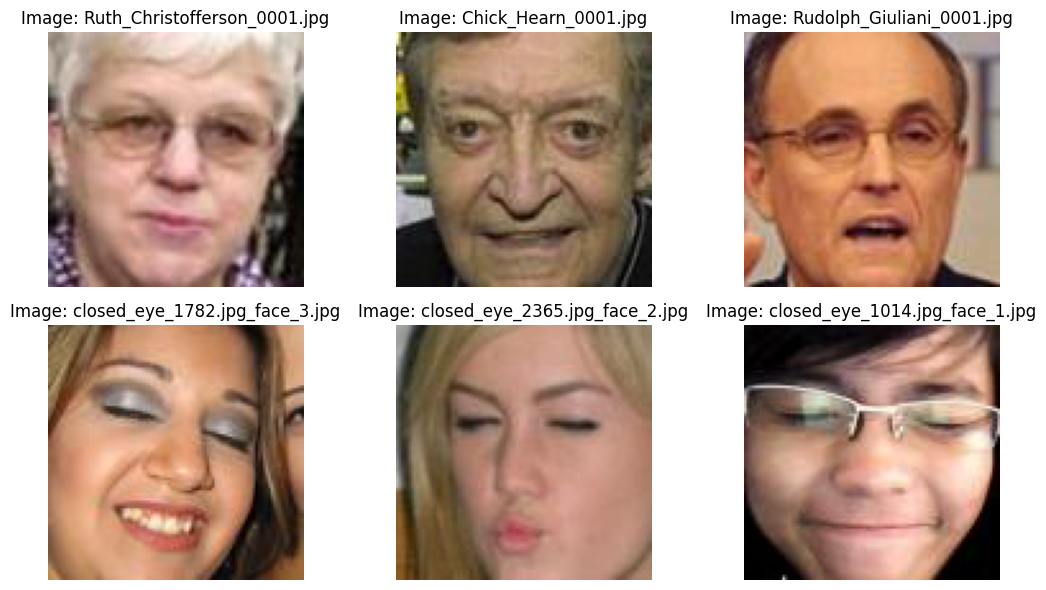

In [73]:
# Select 3 random open eye samples
open_eye_samples = df_images[df_images['category'] == 'OpenFace'].sample(n=3)

# Select 3 random closed eye samples
closed_eye_samples = df_images[df_images['category'] == 'ClosedFace'].sample(n=3)

# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(11, 6))

# Iterate over the open eye samples and plot them
for i, (index, row) in enumerate(open_eye_samples.iterrows()):
    # Get the image and its metadata
    image = row['image']
    image_name = row['image_name']
    
    # Get the corresponding subplot
    ax = axes[i // 3, i % 3]
    
    # Plot the image
    ax.imshow(image)
    ax.set_title(f"Image: {image_name}")
    ax.axis('off')

# Iterate over the closed eye samples and plot them
for i, (index, row) in enumerate(closed_eye_samples.iterrows()):
    # Get the image and its metadata
    image = row['image']
    image_name = row['image_name']
    
    # Get the corresponding subplot
    ax = axes[(i+3) // 3, (i+3) % 3]
    
    # Plot the image
    ax.imshow(image)
    ax.set_title(f"Image: {image_name}")
    ax.axis('off')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

### Checking for corrupt images

In [74]:
corrupted_images = []

# Iterate through the dataframe
for index, row in df_images.iterrows():
    image_path = row['image_path']
    
    # Try to open the image file
    try:
        with Image.open(image_path) as img:
            pass
    except Exception as e:
        corrupted_images.append(image_path)

# Print the list of corrupted images
if len(corrupted_images) == 0:
    print("No corrupted images identified")
else:
    for image_path in corrupted_images:
        print(image_path)


No corrupted images identified


### Check for duplicates

In [75]:
#Check for any duplicate images

# Create an empty set to store the hashes
hashes = set()

# Initialize the count of duplicate images
duplicate_count = 0

# Iterate over the image paths in the DataFrame
for image_path in df_images['image_path']:
    # Read the image file as binary data
    with open(image_path, 'rb') as f:
        # Calculate the hash of the image data
        image_hash = hashlib.md5(f.read()).hexdigest()
    
    # Check if the hash is already in the set
    if image_hash in hashes:
        duplicate_count += 1
    else:
        hashes.add(image_hash)

# Print the count of duplicate images
print(f"Number of duplicate images: {duplicate_count}")

Number of duplicate images: 0


### Resolution, Aspect Ratio, and RGB Anomalities check

In [76]:
# Calculate resolution and aspect ratio
def calculate_resolution_and_aspect_ratio(df):
    resolutions = []
    aspect_ratios = []

    for index, row in df.iterrows():
        img_path = row['image_path']
        try:
            img = Image.open(img_path)
            resolution = img.size  # (width, height)
            aspect_ratio = resolution[0] / resolution[1] if resolution[1] != 0 else 0
            resolutions.append(resolution)
            aspect_ratios.append(aspect_ratio)
        except Exception as e:
            print(f"Error processing image {img_path}: {e}")
            resolutions.append((0, 0))
            aspect_ratios.append(0)
    
    df['resolution'] = resolutions
    df['aspect_ratio'] = aspect_ratios
    return df

# Calculate resolutions and aspect ratios using balanced_df
df_images = calculate_resolution_and_aspect_ratio(df_images)

# Check unique resolutions and aspect ratios
unique_resolutions = len(set(df_images['resolution'].tolist()))
unique_aspect_ratios = len(set(df_images['aspect_ratio'].tolist()))

print(f"Unique number of resolutions: {unique_resolutions}")
print(f"Unique number of aspect ratios: {unique_aspect_ratios}")

# Print specific resolution and aspect ratio
print(f"Specific resolution: {df_images['resolution'].iloc[0]}")
print(f"Specific aspect ratio: {df_images['aspect_ratio'].iloc[0]}")

Unique number of resolutions: 1
Unique number of aspect ratios: 1
Specific resolution: (100, 100)
Specific aspect ratio: 1.0


In [77]:
def check_rgb_anomalies(df):
    total_checked = 0
    anomalies_count = 0
    anomalies = []

    for index, row in df.iterrows():
        img_path = row['image_path']
        total_checked += 1
        try:
            with Image.open(img_path) as img:
                if img.mode == 'RGB':
                    avg_color = np.mean(np.array(img), axis=(0, 1))
                    if not np.all((avg_color > 5) & (avg_color < 250)):
                        anomalies_count += 1
                        anomalies.append(img_path)
        except UnidentifiedImageError:
            continue
    return total_checked, anomalies_count, anomalies

# Check RGB anomalies using balanced_df
total_checked, anomalies_count, anomalies = check_rgb_anomalies(df_images)

print(f"Checked {total_checked} images, found {anomalies_count} RGB anomalies.")
print("List of images with anomalies:")
for anomaly in anomalies:
    print(anomaly)

Checked 2423 images, found 0 RGB anomalies.
List of images with anomalies:


### Eye Cropping

In [108]:
### Cropping Eyes
closed_output_folder = os.path.join(base_path, 'Closed_Cropped')
open_output_folder = os.path.join(base_path, 'Open_Cropped')

# Ensure the output folders exist
os.makedirs(closed_output_folder, exist_ok=True)
os.makedirs(open_output_folder, exist_ok=True)

In [109]:
def process_eye_patches(image_folder, coords_file, output_folder):
    total_attempts = 0
    successful_crops = 0

    # Read the coordinates file
    with open(coords_file, 'r') as file:
        lines = file.readlines()

    # Process each line in the coordinates file
    for line in lines:
        total_attempts += 1  # Increment attempt counter for each line processed
        parts = line.strip().split()
        image_name = parts[0]
        left_eye_x, left_eye_y = int(parts[1]), int(parts[2])
        right_eye_x, right_eye_y = int(parts[3]), int(parts[4])

        # Calculate the path to the image file
        image_path = os.path.join(image_folder, image_name)

        try:
            # Load the image
            image = Image.open(image_path)

            # Calculate bounding boxes for left and right eyes
            left_box = (left_eye_x - 12, left_eye_y - 12, left_eye_x + 12, left_eye_y + 12)
            right_box = (right_eye_x - 12, right_eye_y - 12, right_eye_x + 12, right_eye_y + 12)

            # Crop the eye patches
            left_eye_patch = image.crop(left_box)
            right_eye_patch = image.crop(right_box)

            # Save the eye patches
            left_eye_patch.save(os.path.join(output_folder, f'{image_name}_left_eye.jpg'))
            right_eye_patch.save(os.path.join(output_folder, f'{image_name}_right_eye.jpg'))

            successful_crops += 2  # Two successful crops for each image (left and right eyes)
        except FileNotFoundError:
            print(f"File not found: {image_path}")
        except Exception as e:
            print(f"Error processing {image_name}: {str(e)}")

    return total_attempts, successful_crops

In [110]:
# Process closed face images
closed_total, closed_successful = process_eye_patches(closed_face_dir, closed_face_info, closed_output_folder)
print(f"Closed Faces: Total images attempted: {closed_total}, Total successful eye crops: {closed_successful}")

# Process open face images
open_total, open_successful = process_eye_patches(open_face_dir, open_face_info, open_output_folder)
print(f"Open Faces: Total images attempted: {open_total}, Total successful eye crops: {open_successful}")

Closed Faces: Total images attempted: 1192, Total successful eye crops: 2384
Open Faces: Total images attempted: 1231, Total successful eye crops: 2462


### Resize images from 24x24 pixels to 224x224

In [81]:
# Define the cropped image directories
closed_output_folder = os.path.join(base_path, 'Closed_Cropped')
open_output_folder = os.path.join(base_path, 'Open_Cropped')

# Ensure the output folders exist
os.makedirs(closed_output_folder, exist_ok=True)
os.makedirs(open_output_folder, exist_ok=True)

# Define the output directories for resized and normalized images
output_dir_closed = os.path.join(base_path, 'Resized_Normalized_Images', 'Closed')
output_dir_open = os.path.join(base_path, 'Resized_Normalized_Images', 'Open')
os.makedirs(output_dir_closed, exist_ok=True)
os.makedirs(output_dir_open, exist_ok=True)

In [82]:
# Function to resize, normalize, and save images
def resize_normalize_and_save_images(images, target_size=(224, 224), output_dir=''):
    resized_images = []
    for img_path in images:
        try:
            with Image.open(img_path) as img:
                img = img.resize(target_size)
                img_array = np.array(img) / 255.0
                resized_images.append(img_array)

                # Save the image
                output_path = os.path.join(output_dir, os.path.basename(img_path))
                img.save(output_path)
        except UnidentifiedImageError:
            print(f"Unidentified image error for {img_path}")
            continue
        except Exception as e:
            print(f"Error processing {img_path}: {str(e)}")
            continue
    return resized_images

In [83]:
# Get the list of cropped images
closed_images = [os.path.join(closed_output_folder, f) for f in os.listdir(closed_output_folder) if f.endswith('.jpg')]
open_images = [os.path.join(open_output_folder, f) for f in os.listdir(open_output_folder) if f.endswith('.jpg')]

# Resize, normalize, and save the cropped images
resized_closed_images = resize_normalize_and_save_images(closed_images, output_dir=output_dir_closed)
resized_open_images = resize_normalize_and_save_images(open_images, output_dir=output_dir_open)

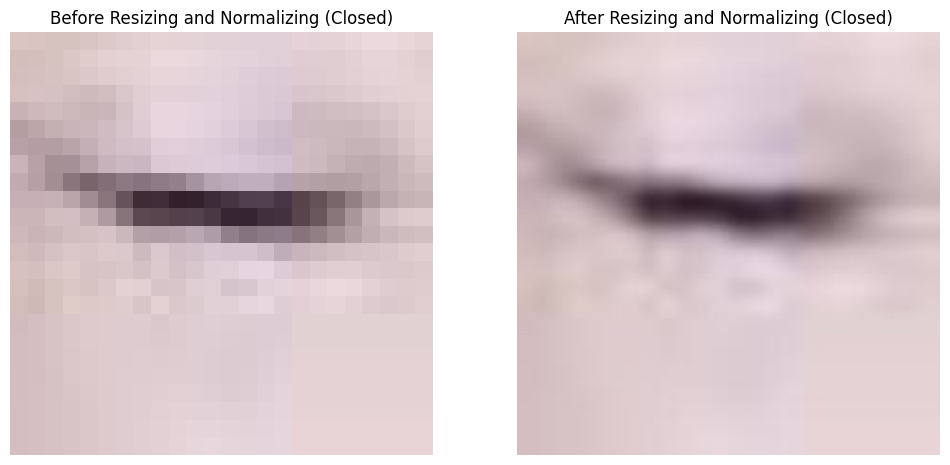

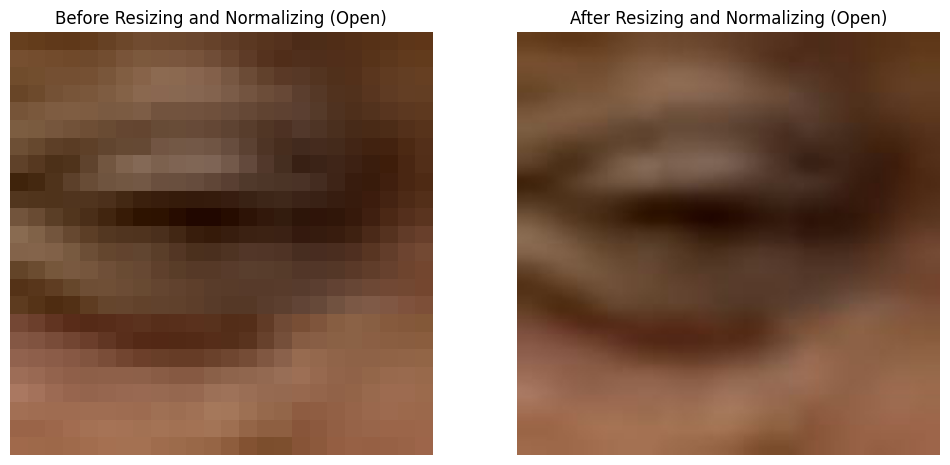

In [84]:
# Display a before and after of an image that has been resized and normalized
if len(closed_images) > 0:
    before_image_path = closed_images[0]
    before_image = Image.open(before_image_path)
    after_image = Image.open(os.path.join(output_dir_closed, os.path.basename(before_image_path)))

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("Before Resizing and Normalizing (Closed)")
    plt.imshow(before_image)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("After Resizing and Normalizing (Closed)")
    plt.imshow(after_image)
    plt.axis('off')

    plt.show()
else:
    print("No closed images available for display.")

if len(open_images) > 0:
    before_image_path = open_images[0]
    before_image = Image.open(before_image_path)
    after_image = Image.open(os.path.join(output_dir_open, os.path.basename(before_image_path)))

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("Before Resizing and Normalizing (Open)")
    plt.imshow(before_image)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("After Resizing and Normalizing (Open)")
    plt.imshow(after_image)
    plt.axis('off')

    plt.show()
else:
    print("No open images available for display.")

### Split data into Test-Train and export

In [85]:
# Source directories for closed and open eye images
closed_source_dir = os.path.join(base_path, 'Closed_Cropped')
open_source_dir = os.path.join(base_path, 'Open_Cropped')

# Directories to save the split datasets for closed and open eyes
closed_train_dir = os.path.join(base_path, 'TrainingSet', 'Closed')
closed_test_dir = os.path.join(base_path, 'TestSet', 'Closed')
open_train_dir = os.path.join(base_path, 'TrainingSet', 'Open')
open_test_dir = os.path.join(base_path, 'TestSet', 'Open')

# Create the directories if they don't exist
os.makedirs(closed_train_dir, exist_ok=True)
os.makedirs(closed_test_dir, exist_ok=True)
os.makedirs(open_train_dir, exist_ok=True)
os.makedirs(open_test_dir, exist_ok=True)

# Set random seed for reproducibility
random.seed(42)

In [86]:
def split_and_copy_images(source_dir, train_dir, test_dir, split_ratio=0.8):
    # Get list of all image files in the source directory
    all_images = [os.path.join(source_dir, img) for img in os.listdir(source_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]
    
    # Shuffle the list of images
    random.shuffle(all_images)
    
    # Calculate the split index
    split_index = int(len(all_images) * split_ratio)
    
    # Split the images into training and test sets
    train_images = all_images[:split_index]
    test_images = all_images[split_index:]
    
    # Function to copy images to the respective directories
    def copy_images(image_paths, destination_dir):
        for img_path in image_paths:
            shutil.copy(img_path, destination_dir)
    
    # Copy images to the training and test directories
    copy_images(train_images, train_dir)
    copy_images(test_images, test_dir)
    
    return len(all_images), len(train_images), len(test_images)

In [87]:
# Split and copy closed eye images
total_closed, train_closed, test_closed = split_and_copy_images(closed_source_dir, closed_train_dir, closed_test_dir)

# Split and copy open eye images
total_open, train_open, test_open = split_and_copy_images(open_source_dir, open_train_dir, open_test_dir)

print(f"Total closed eye images: {total_closed}")
print(f"Training closed eye images: {train_closed}")
print(f"Test closed eye images: {test_closed}")

print(f"Total open eye images: {total_open}")
print(f"Training open eye images: {train_open}")
print(f"Test open eye images: {test_open}")

Total closed eye images: 2384
Training closed eye images: 1907
Test closed eye images: 477
Total open eye images: 2462
Training open eye images: 1969
Test open eye images: 493


## Visualizing the eye cropping process

In [101]:
# Define the cropped image directories
closed_output_folder = os.path.join(base_path, 'Closed_Cropped')
open_output_folder = os.path.join(base_path, 'Open_Cropped')

# Ensure the output folders exist
os.makedirs(closed_output_folder, exist_ok=True)
os.makedirs(open_output_folder, exist_ok=True)

In [105]:
# Function to process eye patches and save cropped images
def process_eye_patches(image_folder, coords_file, output_folder):
    total_attempts = 0
    successful_crops = 0
    example_images = []  # To store images for visualization

    # Read the coordinates file
    with open(coords_file, 'r') as file:
        lines = file.readlines()

    # Process each line in the coordinates file
    for line in lines:
        total_attempts += 1  # Increment attempt counter for each line processed
        parts = line.strip().split()
        image_name = parts[0]
        left_eye_x, left_eye_y = int(parts[1]), int(parts[2])
        right_eye_x, right_eye_y = int(parts[3]), int(parts[4])

        # Calculate the path to the image file
        image_path = os.path.join(image_folder, image_name)

        try:
            # Load the image
            image = Image.open(image_path)

            # Calculate bounding boxes for left and right eyes
            left_box = (left_eye_x - 12, left_eye_y - 12, left_eye_x + 12, left_eye_y + 12)
            right_box = (right_eye_x - 12, right_eye_y - 12, right_eye_x + 12, right_eye_y + 12)

            # Crop the eye patches
            left_eye_patch = image.crop(left_box)
            right_eye_patch = image.crop(right_box)

            # Save the eye patches
            left_eye_patch.save(os.path.join(output_folder, f'{image_name}_left_eye.jpg'))
            right_eye_patch.save(os.path.join(output_folder, f'{image_name}_right_eye.jpg'))

            successful_crops += 2  # Two successful crops for each image (left and right eyes)

            # Store example images for visualization
            example_images.append((image, left_box, right_box, left_eye_patch, right_eye_patch))

            # Limit to 3 examples for visualization
            if len(example_images) >= 3:
                break

        except FileNotFoundError:
            print(f"File not found: {image_path}")
        except Exception as e:
            print(f"Error processing {image_name}: {str(e)}")

    return total_attempts, successful_crops, example_images

In [106]:
# Process closed face images
closed_total, closed_successful, closed_examples = process_eye_patches(closed_face_dir, closed_face_info, closed_output_folder)
print(f"Closed Faces: Total images attempted: {closed_total}, Total successful eye crops: {closed_successful}")

# Process open face images
open_total, open_successful, open_examples = process_eye_patches(open_face_dir, open_face_info, open_output_folder)
print(f"Open Faces: Total images attempted: {open_total}, Total successful eye crops: {open_successful}")

Closed Faces: Total images attempted: 3, Total successful eye crops: 6
Open Faces: Total images attempted: 3, Total successful eye crops: 6


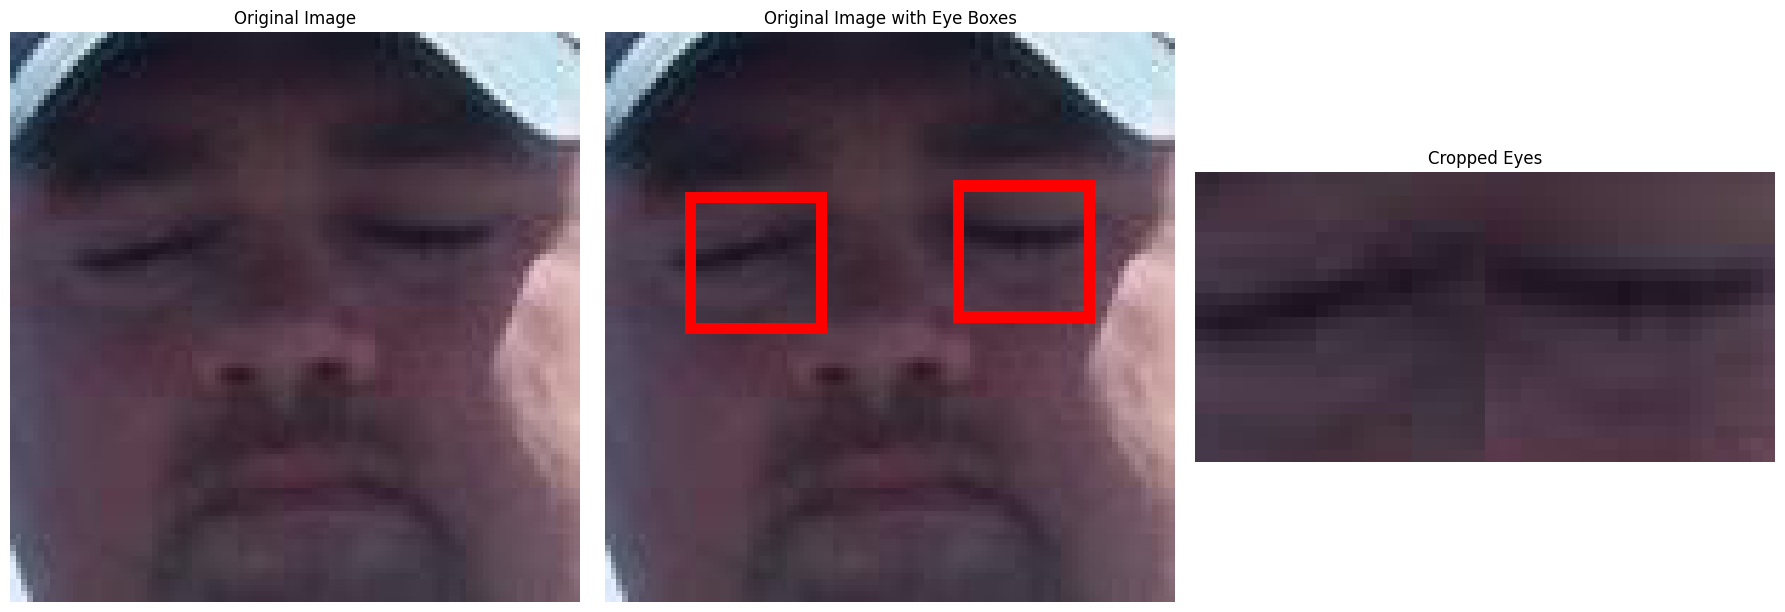

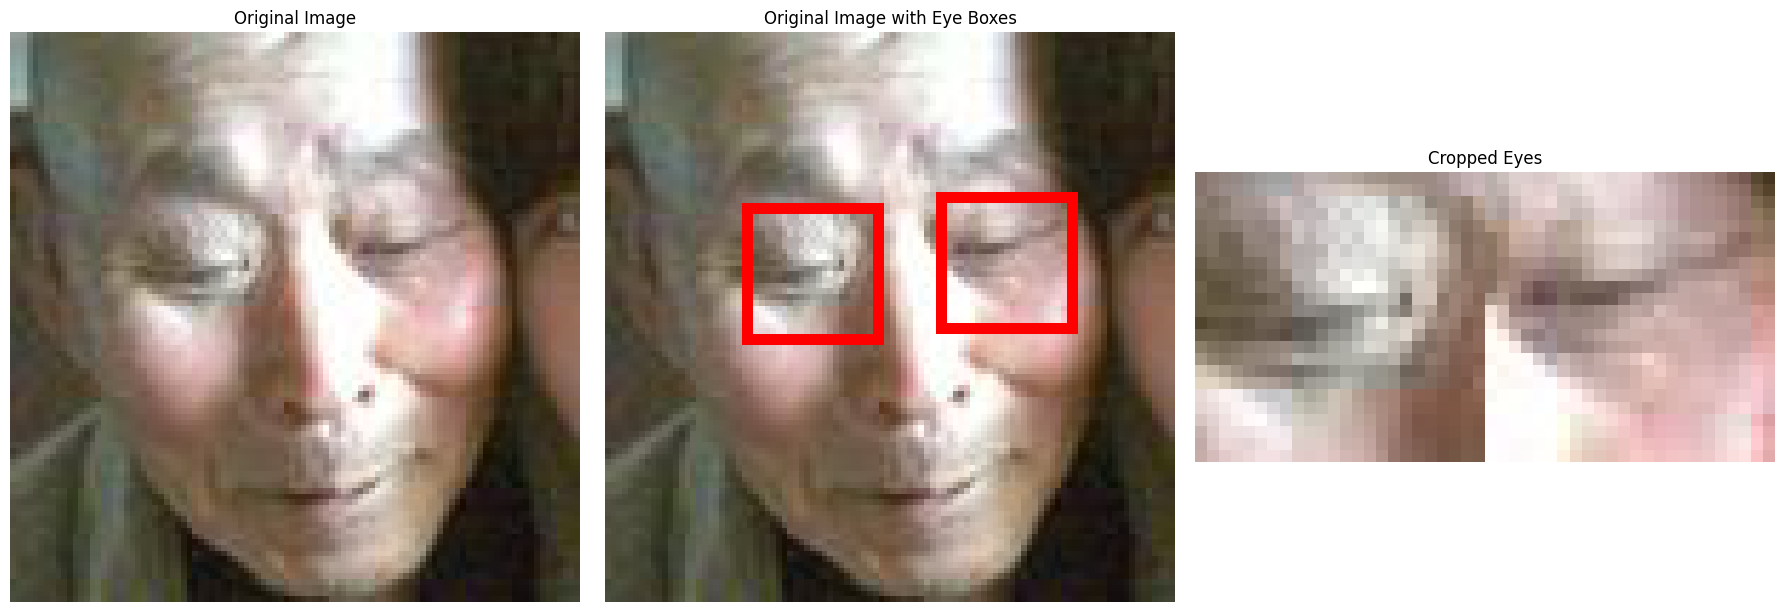

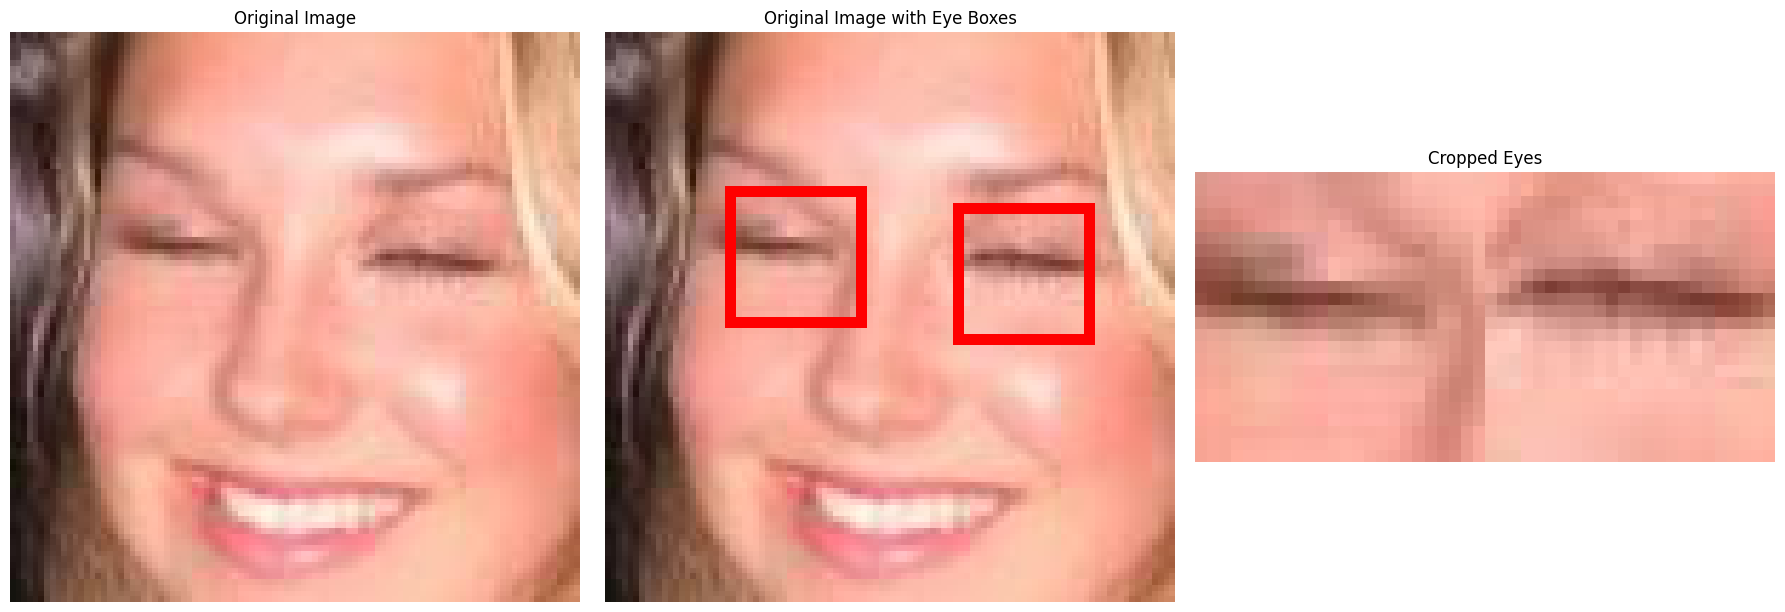

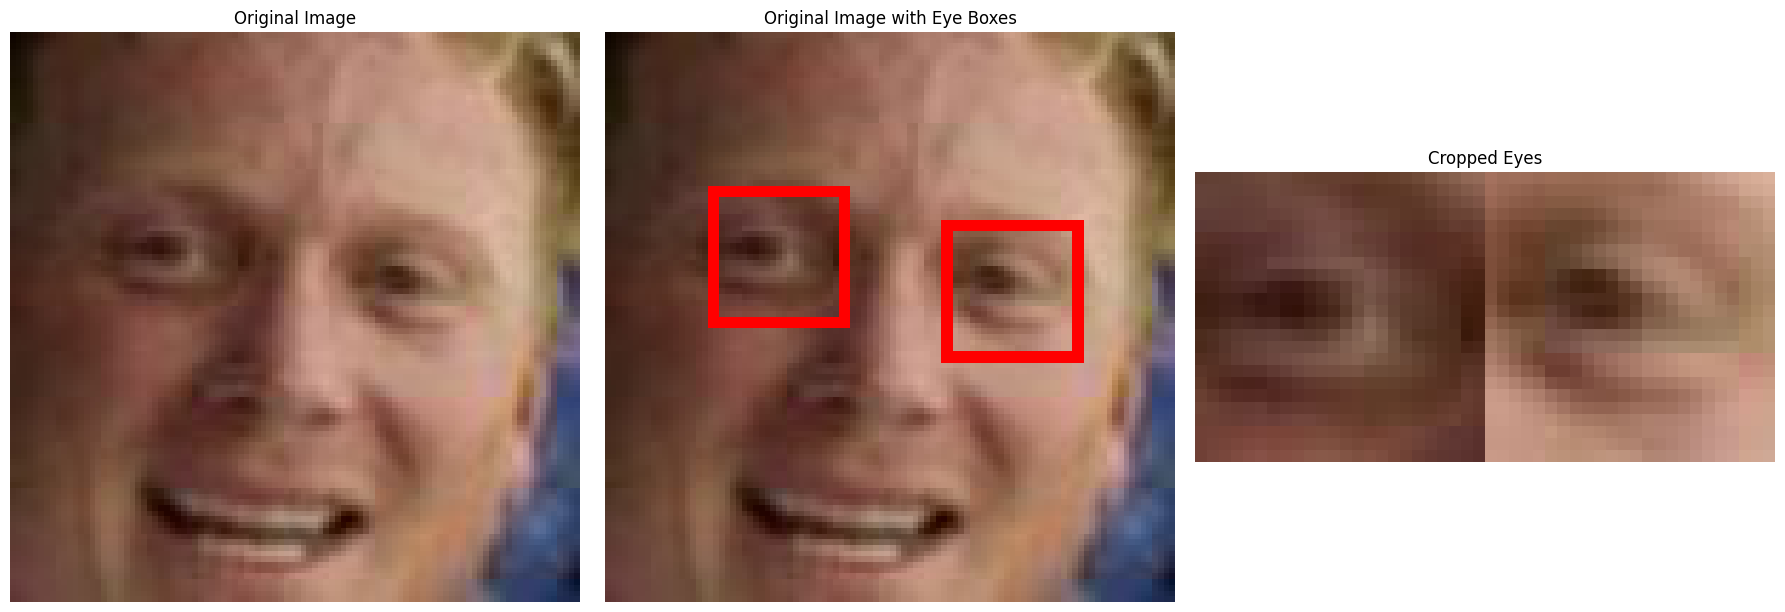

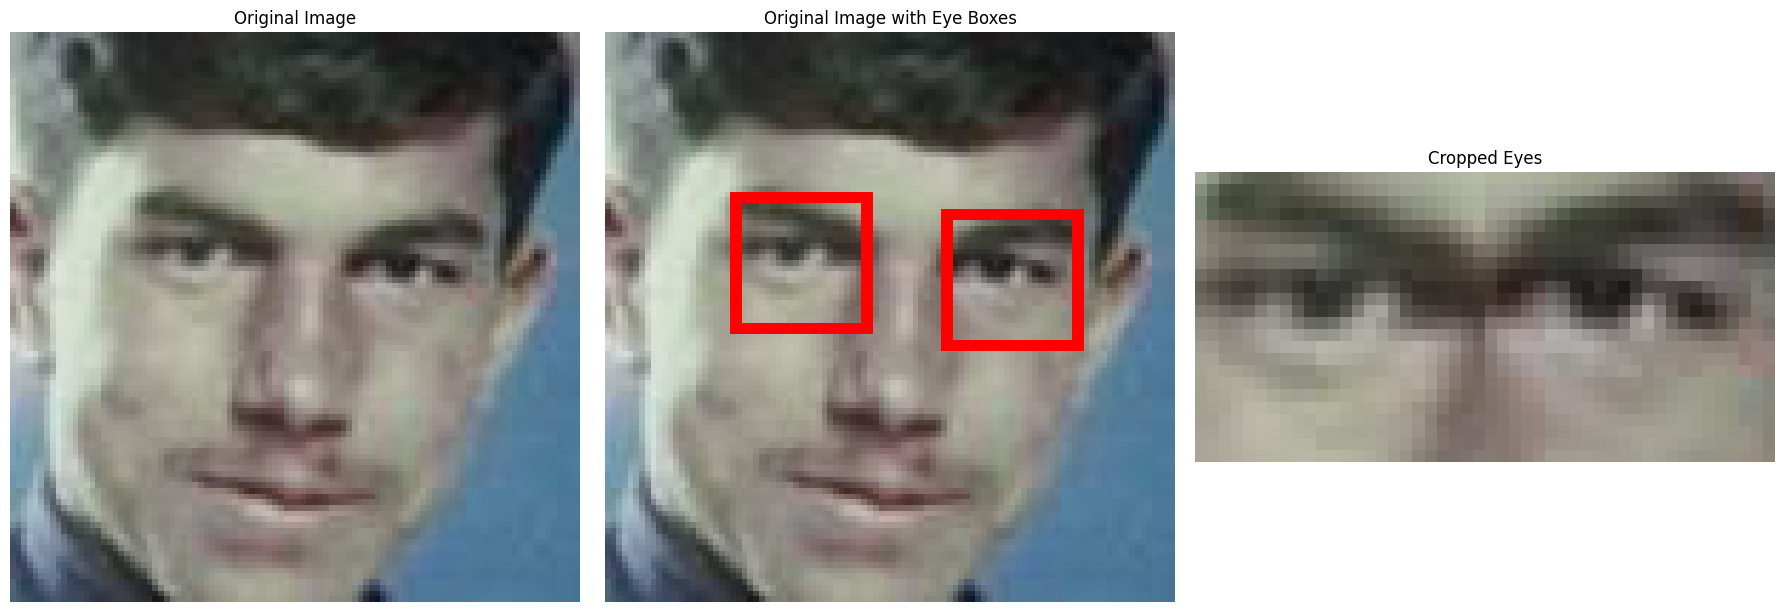

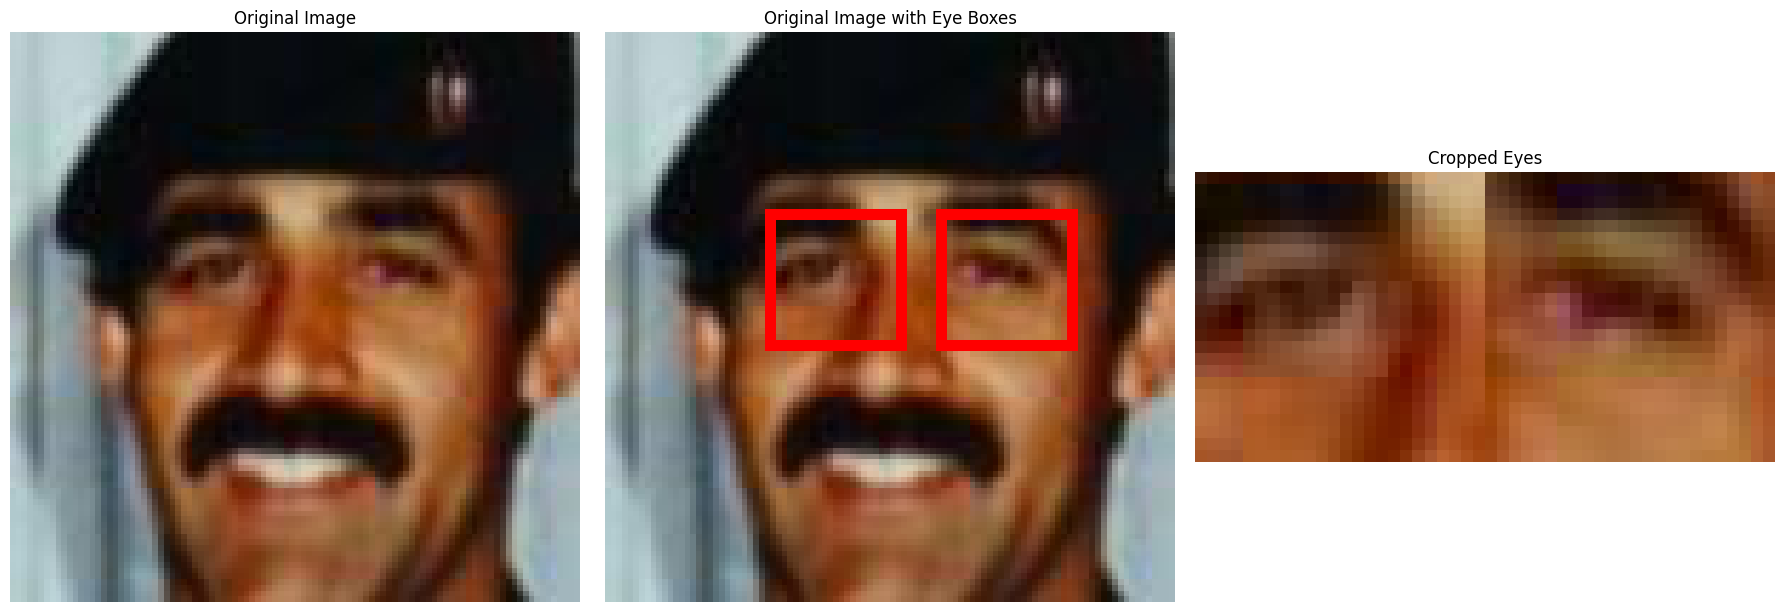

In [107]:
# Visualization function
def visualize_eye_cropping(examples):
    for example in examples:  # Display up to 3 examples
        original_image, left_box, right_box, left_eye_patch, right_eye_patch = example

        # Create a copy of the original image to draw bounding boxes
        image_with_boxes = original_image.copy()
        draw = ImageDraw.Draw(image_with_boxes)
        draw.rectangle(left_box, outline="red", width=2)
        draw.rectangle(right_box, outline="red", width=2)

        # Plot the images
        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        plt.title("Original Image")
        plt.imshow(original_image)
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("Original Image with Eye Boxes")
        plt.imshow(image_with_boxes)
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title("Cropped Eyes")
        plt.imshow(np.hstack((left_eye_patch, right_eye_patch)))
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# Visualize closed eye examples
visualize_eye_cropping(closed_examples)

# Visualize open eye examples
visualize_eye_cropping(open_examples)